# TRYING ... to compute EFE from ERA5 monthly levelwise data
Doing the vertical integral of v*MSE first and then computed its divergent component

In [1]:
import numpy as np
import xarray as xr

def make_constant_ps_like(sample_da, value_hPa=1000.0):
    """
    Create a constant surface-pressure DataArray on the (lat, lon) grid of 'sample_da'.

    Parameters
    ----------
    sample_da : xr.DataArray or xr.Dataset
        Any object that contains 'lat' and 'lon' coordinates on the target grid.
        Typically use u.isel(plev=0) or v.isel(plev=0) or any 2-D field with (lat, lon).
    value_hPa : float
        Constant surface pressure in hPa (default: 1000 hPa).

    Returns
    -------
    ps : xr.DataArray
        Surface pressure (Pa) with dims ('lat', 'lon') on the same grid as sample_da.
    """
    # get coords from the sample
    lat = sample_da['lat']
    lon = sample_da['lon']

    ps_values = np.full((lat.size, lon.size), value_hPa * 100.0, dtype=np.float32)  # convert hPa -> Pa
    ps = xr.DataArray(
        ps_values,
        coords={'lat': lat, 'lon': lon},
        dims=('lat', 'lon'),
        name='ps'
    )
    ps.attrs.update({'units': 'Pa', 'long_name': f'Constant surface pressure ({value_hPa:.0f} hPa)'})
    return ps

In [2]:
def barotropic_mass_correction(u, v, plev, ps):
    """
    Barotropic mass correction following Trenberth (1991)
    and Wei & Bordoni (2020) Supplementary Text S1.

    Parameters
    ----------
    u, v : xr.DataArray
        Zonal and meridional winds (plev, lat, lon)
    plev : xr.DataArray
        Pressure levels in Pa (plev,)
    ps : xr.DataArray
        Surface pressure (lat, lon)

    Returns
    -------
    u_corr, v_corr : xr.DataArray
        Barotropically corrected winds
    """

    g=9.81
    
    n_lev = len(plev)
    dp_vals = np.zeros(n_lev)
    
    # Top level (index 0): use distance to next level
    dp_vals[0] = abs(plev.values[1] - plev.values[0])
    
    # Interior levels: use centered difference (distance to neighbors / 2 on each side)
    for i in range(1, n_lev - 1):
        dp_vals[i] = abs(plev.values[i+1] - plev.values[i-1]) / 2.0
    
    # Bottom level: use distance to previous level
    dp_vals[-1] = abs(plev.values[-1] - plev.values[-2])
    
    # Create DataArray
    dp = xr.DataArray(dp_vals, coords={"plev": plev}, dims=["plev"])

    print("printing dp before u_corr", dp)
    print("printing ps before u_corr", ps)
    
    # -------------------------------------------
    # 2. Vertically integrated mass flux M = (1/g) ∫ v dp
    # -------------------------------------------
    Mx = (u * dp).sum("plev") / g # zonal mass flux
    My = (v * dp).sum("plev") / g # meridional mass flux
    Mx = Mx.fillna(0.0)
    My = My.fillna(0.0)


    # ------------------------------------------------------------
    # 3. Extract DIVERGENT (irrotational) component of M using:
    #       M_div = ∇χ = vw.irrotationalcomponent()
    # ------------------------------------------------------------
    # vwM = VectorWind(Mx, My)
    # Mx_div, My_div = vwM.irrotationalcomponent()
    Mx_div_list = []
    My_div_list = []
    
    for t in range(Mx.time.size):
        vwM = VectorWind(
            Mx.isel(time=t),
            My.isel(time=t)
        )
        
        Mx_d, My_d = vwM.irrotationalcomponent()
        
        Mx_div_list.append(
            xr.DataArray(
                Mx_d,
                coords={"lat": Mx.lat, "lon": Mx.lon},
                dims=("lat", "lon")
            )
        )
        
        My_div_list.append(
            xr.DataArray(
                My_d,
                coords={"lat": My.lat, "lon": My.lon},
                dims=("lat", "lon")
            )
        )
    
    Mx_div = xr.concat(Mx_div_list, dim="time")
    My_div = xr.concat(My_div_list, dim="time")
    
    Mx_div = Mx_div.assign_coords(time=Mx.time)
    My_div = My_div.assign_coords(time=My.time)

    # THIS IS THE KEY FIX:
    p_t = plev.min()  # top level pressure
    atmospheric_mass = (ps - p_t) / g  # This is in kg/m²
    print("atmospheric_mass",atmospheric_mass)
    
    # ------------------------------------------------------------
    # 4. Barotropic correction: M_bt = - M_div / p_s
    #
    # Because we want:
    #    M + p_s * u_bt = M_nondivergent
    # => p_s * u_bt = - M_div
    # ------------------------------------------------------------
    u_bt = -Mx_div / atmospheric_mass ;#ps
    v_bt = -My_div / atmospheric_mass ;#ps

    # ------------------------------------------------------------
    # 5. Expand barotropic correction to all vertical levels
    # ------------------------------------------------------------
    u_bt_3D = u_bt.expand_dims({"plev": u.plev}, axis=0)
    v_bt_3D = v_bt.expand_dims({"plev": v.plev}, axis=0)

    u_corr = u + u_bt_3D
    v_corr = v + v_bt_3D

    return u_corr, v_corr


In [15]:
# def mass_weighted_integral_simple(data, g=9.81):
#     """
#     Simple mass-weighted integral using composite Simpson's rule.
    
#     Parameters
#     ----------
#     data : xr.DataArray
#         Data to integrate (time, plev, lat, lon)
#     g : float
#         Gravity (m/s²)
    
#     Returns
#     -------
#     xr.DataArray
#         Vertically integrated data
#     """
#     from scipy.integrate import simpson
    
#     # Get pressure levels
#     plev = data.pressure_level.values*100
    
#     # Fill NaNs
#     data_filled = data.fillna(0.0)
    
#     # Load data if it's a dask array (to avoid dask issues)
#     if hasattr(data_filled.data, 'compute'):
#         data_filled = data_filled.compute()
    
#     # Use scipy.integrate.simpson
#     # Find which axis is 'plev'
#     plev_axis = data.dims.index('pressure_level')
    
#     # Integrate using Simpson's rule
#     integrated = simpson(data_filled.values, x=plev, axis=plev_axis)
    
#     # Create output DataArray
#     output_dims = [d for d in data.dims if d != 'pressure_level']
#     output_coords = {d: data[d] for d in output_dims}
    
#     result = xr.DataArray(
#         integrated / g,
#         coords=output_coords,
#         dims=output_dims
#     )
    
#     return result

#######################################################################

def mass_weighted_integral_simple(data, g=9.81):
    from scipy.integrate import simpson
    
    # Get pressure levels and convert to Pa
    plev = data.pressure_level.values * 100
    
    # REVERSE both data and pressure for integration (top to surface)
    plev_reversed = plev[::-1]  # Now ascending: 100, 200, ..., 1000
    
    data_filled = data.fillna(0.0)
    if hasattr(data_filled.data, 'compute'):
        data_filled = data_filled.compute()
    
    plev_axis = data.dims.index('pressure_level')
    
    # Reverse data along pressure axis
    data_reversed = np.flip(data_filled.values, axis=plev_axis)
    
    # Integrate (now from low to high pressure)
    integrated = simpson(data_reversed, x=plev_reversed, axis=plev_axis)
    
    output_dims = [d for d in data.dims if d != 'pressure_level']
    output_coords = {d: data[d] for d in output_dims}
    
    result = xr.DataArray(
        integrated / g,
        coords=output_coords,
        dims=output_dims
    )
    
    return result

In [16]:
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from windspharm.standard import VectorWind
import cftime

In [17]:
# ----------------------------
# CONSTANTS
# ----------------------------
Cp = 1004.0        # J kg-1 K-1
Lv = 2.5e6         # J kg-1
g  = 9.81          # m s-2
R  = 6.371e6       # Earth radius (m)

In [18]:
from windspharm.xarray import VectorWind

def windspharm_time_loop(uh_int, vh_int):
    """
    Compute divergent component for each time step
    """
    Flambda_div_list = []
    Fphi_div_list = []
    
    for t in range(len(uh_int.valid_time)):
        # Extract single time step
        u_t = uh_int.isel(valid_time=t)
        v_t = vh_int.isel(valid_time=t)
        
        # VectorWind requires (lat, lon) with no NaNs
        u_filled = u_t.fillna(0.0)
        v_filled = v_t.fillna(0.0)
        
        # Compute divergent component
        vw = VectorWind(u_filled, v_filled)
        u_div, v_div = vw.irrotationalcomponent()  # Changed here!
        
        Flambda_div_list.append(u_div)
        Fphi_div_list.append(v_div)
    
    # Concatenate back along time dimension
    Flambda_div = xr.concat(Flambda_div_list, dim='valid_time')
    Fphi_div = xr.concat(Fphi_div_list, dim='valid_time')
    
    # Assign time coordinates
    Flambda_div = Flambda_div.assign_coords(time=uh_int.valid_time)
    Fphi_div = Fphi_div.assign_coords(time=vh_int.valid_time)
    
    return Flambda_div, Fphi_div



In [19]:
ds = xr.open_dataset("ERA5_Temp_SpHum_Geopot_u_v_2022.nc")
ds

<xarray.Dataset> Size: 2GB
Dimensions:         (valid_time: 12, pressure_level: 10, latitude: 721,
                     longitude: 1440)
Coordinates:
    number          int64 8B ...
  * valid_time      (valid_time) datetime64[ns] 96B 2022-01-01 ... 2022-12-01
  * pressure_level  (pressure_level) float64 80B 1e+03 900.0 ... 200.0 100.0
  * latitude        (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude       (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    expver          (valid_time) <U4 192B ...
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 498MB ...
    q               (valid_time, pressure_level, latitude, longitude) float32 498MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 498MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 498MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 498MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-10T12:38 GRIB to CDM+CF via cfgrib-0.9.1...

In [20]:
# ----------------------------
# BLOCK 1: READING VARIABLES (lat,lon,lev,time)
# ----------------------------

ta_mean = ds.t ;#.isel(pressure_level=[7,9])
q_mean  = ds.q ;#.isel(pressure_level=[7,9])
z_mean  = ds.z ;#.isel(pressure_level=[7,9])
u_mean  = ds.u ;#.isel(pressure_level=[7,9])
v_mean  = ds.v ;#.isel(pressure_level=[7,9])

# ta_mean = ds.t.isel(valid_time=0, pressure_level=8)
# q_mean  = ds.q.isel(valid_time=0, pressure_level=8)
# z_mean  = ds.z.isel(valid_time=0, pressure_level=8)
# u_mean  = ds.u.isel(valid_time=0, pressure_level=8)
# v_mean  = ds.v.isel(valid_time=0, pressure_level=8)

In [21]:
ta_mean=ta_mean.mean("valid_time")
q_mean=q_mean.mean("valid_time")
z_mean=z_mean.mean("valid_time")
u_mean=u_mean.mean("valid_time")
v_mean=v_mean.mean("valid_time")

In [22]:
ds_n = xr.open_dataset("/home/users/bidyut/UoE/20260112_Basic_Analysis/cds.climate.copernicus.eu/latent-heat-flux-northward_monthly_202201_v1.0.nc")

ds_n

<xarray.Dataset> Size: 4MB
Dimensions:    (time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 8B 2022-01-15
  * latitude   (latitude) float32 3kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    lhfln      (time, latitude, longitude) float32 4MB ...
Attributes:
    Conventions:  CF-1.6
    version:      v1.0

In [29]:
# Use RAW winds (no barotropic correction)
u_filled = u_mean.fillna(0.0)
v_filled = v_mean.fillna(0.0)

# Compute MSE
h = Cp * ta_mean + Lv * q_mean + g * z_mean
h_on_u = h.interp(latitude=u_filled.latitude, longitude=u_filled.longitude, method='linear')
h_on_v = h.interp(latitude=v_filled.latitude, longitude=v_filled.longitude, method='linear')

# MSE fluxes
uh = u_filled * h_on_u
vh = v_filled * h_on_v

# Vertical integration
uh_int = mass_weighted_integral_simple(uh, g=9.81)
vh_int = mass_weighted_integral_simple(vh, g=9.81)
# #=================================================
# # Regrid to CDS grid BEFORE divergent component
# target_lat = ds_n.latitude.values
# target_lon = ds_n.longitude.values

# uh_int_regrid = uh_int.interp(latitude=target_lat, longitude=target_lon, method='linear')
# vh_int_regrid = vh_int.interp(latitude=target_lat, longitude=target_lon, method='linear')

# # Sort descending
# uh_int_regrid = uh_int_regrid.sortby('latitude', ascending=False)
# vh_int_regrid = vh_int_regrid.sortby('latitude', ascending=False)

# # Rename to match CDS
# uh_int_regrid = uh_int_regrid.rename({'latitude': 'latitude', 'longitude': 'longitude'})
# vh_int_regrid = vh_int_regrid.rename({'latitude': 'latitude', 'longitude': 'longitude'})
# #=================================================
# # Use THE SAME windspharm_time_loop function that worked for ERA5
# Flambda_div, Fphi_div = windspharm_time_loop(uh_int_regrid, vh_int_regrid)

# Fphi_div_mean = Fphi_div.mean(dim='time')

# Compute divergent component
# vw = VectorWind(-uh_int_regrid, -vh_int_regrid)
vw = VectorWind(uh_int, vh_int)
Flambda_div, Fphi_div =  vw.irrotationalcomponent()  # Changed here!


# Plot and check EFE

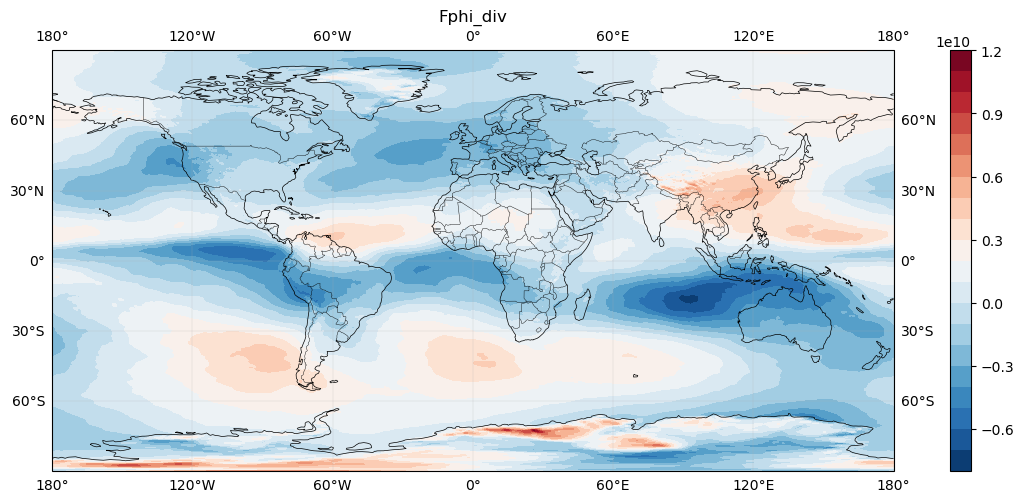

In [30]:
# Select a time index (e.g., month 0 = January)
import cartopy.crs as ccrs
import cartopy.feature as cfeature

Fphi_div = xr.DataArray(Fphi_div, dims=vh_int.dims, coords=vh_int.coords)
v=Fphi_div

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("Fphi_div")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



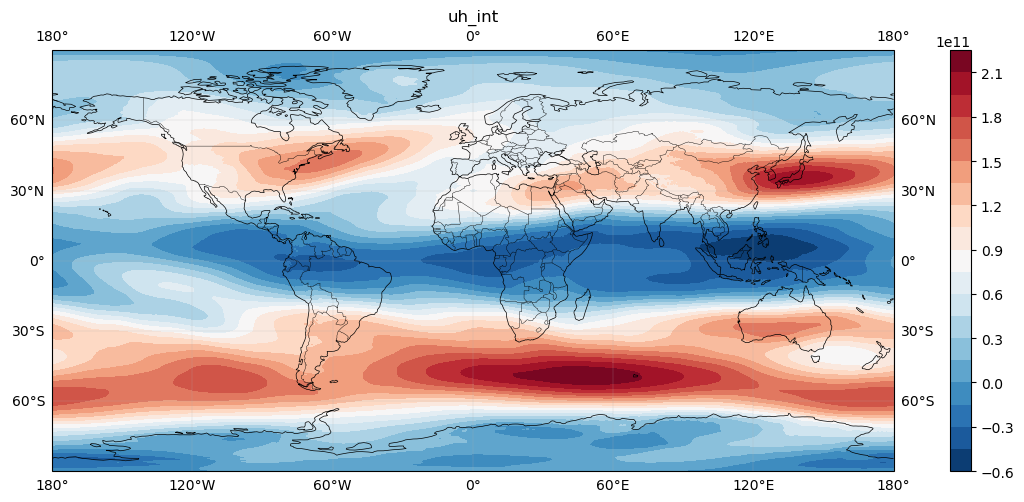

In [25]:
# Select a time index (e.g., month 0 = January)
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Fphi_div = xr.DataArray(Fphi_div, dims=vh_int_regrid.dims, coords=vh_int_regrid.coords)
v=uh_int

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("uh_int")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

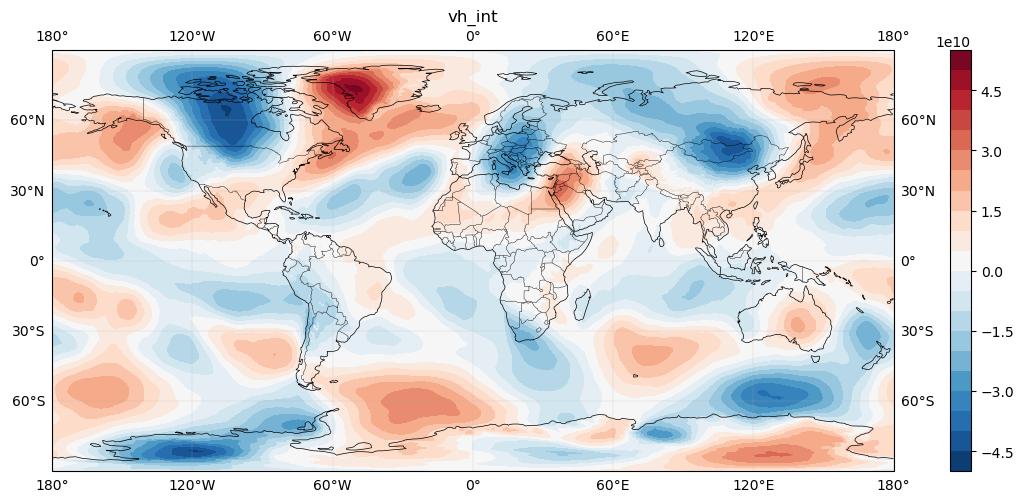

In [26]:
# Select a time index (e.g., month 0 = January)
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Fphi_div = xr.DataArray(Fphi_div, dims=vh_int_regrid.dims, coords=vh_int_regrid.coords)
v=vh_int

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("vh_int")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()

In [ ]:
# ----------------------------
# BLOCK 2.1 : MOIST STATIC ENERGY (lat,lon,lev,time)
# ----------------------------
h = Cp * ta_mean + Lv * q_mean + z_mean
# h_on_v = h.interp(latitude=v_mean.latitude, longitude=v_mean.longitude, pressure_level=v_mean.pressure_level, method="linear")
h_on_v = h.interp(latitude=v_mean.latitude, longitude=v_mean.longitude, method="linear")

In [ ]:
# Select a time index (e.g., month 0 = January)


v=h_on_v.sel(latitude=slice(90,-90))

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("h_on_v")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



In [ ]:
# Zonal wind * MSE
uh = u_mean * h_on_v

# Meridional wind * MSE
vh = v_mean * h_on_v

In [ ]:
# Select a time index (e.g., month 0 = January)


v=uh

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("uh")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



In [ ]:
# Select a time index (e.g., month 0 = January)


v=vh

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("vh")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



In [ ]:
vw = VectorWind(uh, vh)

In [ ]:
Flambda_div, Fphi_div = vw.irrotationalcomponent()

In [ ]:
Fphi_div = xr.DataArray(Fphi_div, dims=vh.dims, coords=vh.coords)

In [ ]:
# Select a time index (e.g., month 0 = January)

Fphi_div = xr.DataArray(Fphi_div, dims=vh.dims, coords=vh.coords)
v=Fphi_div

# --- Plot 1: u-component only ---
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 5))
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

im = ax.contourf(v.longitude, v.latitude, v,
                 levels=20, cmap='RdBu_r', transform=ccrs.PlateCarree())
plt.colorbar(im, ax=ax) ;#, label='uh (m/s or W/m)', shrink=0.7)
ax.set_title("Fphi_div")
plt.tight_layout()
# plt.savefig('uh_map.png', dpi=150)
plt.show()



In [ ]:
# # ----------------------------
# # BLOCK 2.2 : BAROTROPIC CORRECTION (lat,lon,lev,time)
# # ----------------------------
# # Fill NaNs
# u_filled = u_mean.fillna(0.0)
# v_filled = v_mean.fillna(0.0)

# # Barotropic mass correction: sophisticated way
# ps_const = make_constant_ps_like(u_filled.isel(plev=0), value_hPa=1000.0)
# u_corr, v_corr = barotropic_mass_correction(u_filled, v_filled, plev=u_filled.plev, ps=ps_const)

In [ ]:



# # ----------------------------
# # BLOCK 3 : COMPUTE UH and VH (lat,lon,lev,time)
# # ----------------------------
# # Zonal wind * MSE
# uh = u_filled * h_on_v

# # Meridional wind * MSE
# vh = v_filled * h_on_v


# # Ensure monotonic plev and fill NaNs
# uh_sorted = uh.sortby("pressure_level").fillna(0.0)
# vh_sorted = vh.sortby("pressure_level").fillna(0.0)

# plev_vals = np.array(vh_sorted.pressure_level.values, dtype=float)
# order = np.argsort(plev_vals)

# uh_clean = uh_sorted.isel(pressure_level=order).assign_coords(pressure_level=plev_vals[order])
# vh_clean = vh_sorted.isel(pressure_level=order).assign_coords(pressure_level=plev_vals[order])


# ##############################################
# ########### Vertical integration #############
# ##############################################

# # uh_int = uh_clean.integrate("plev") / g
# # vh_int = vh_clean.integrate("plev") / g

# ##############################################
# ########### Mid-point approach ###############
# ##############################################
# # Get the pressure levelsL
# plev = vh_clean.pressure_level*100 ;#Converting to pascal

# # --------------------------------------------
# # Compute layer thickness dp for each level (same as barotropic correction)
# # --------------------------------------------
# n_lev = len(plev)
# dp_vals = np.zeros(n_lev)

# # Top level (index 0): use distance to next level
# dp_vals[0] = abs(plev.values[1] - plev.values[0])

# # Interior levels: use centered difference
# for i in range(1, n_lev - 1):
#     dp_vals[i] = abs(plev.values[i+1] - plev.values[i-1]) / 2.0

# # Bottom level: use distance to previous level
# dp_vals[-1] = abs(plev.values[-1] - plev.values[-2])

# # Create DataArray
# dp = xr.DataArray(dp_vals, coords={"plev": plev}, dims=["pressure_level"])
# dp = dp.assign_coords(plev=plev)



# # BEFORE computing uh_int and vh_int, reorder latitude
# if uh_clean.latitude.values[0] < uh_clean.latitude.values[-1]:
#     uh_clean = uh_clean.sortby('lat', ascending=False)
#     vh_clean = vh_clean.sortby('lat', ascending=False)
#     print("Latitudes reordered to descending")

# # Then compute vertical integration
# # uh_int = (uh_clean * dp).sum("plev") / g
# # vh_int = (vh_clean * dp).sum("plev") / g
# # Correct integration (no /g here)
# # uh_int = (uh_clean * dp).sum("plev")
# # vh_int = (vh_clean * dp).sum("plev")

# # Vertical integration using this function
# uh_int = mass_weighted_integral_simple(uh_clean, g=9.81)
# vh_int = mass_weighted_integral_simple(vh_clean, g=9.81)

# print("uh_int range:", uh_int.min().values, "to", uh_int.max().values)
# print("vh_int range:", vh_int.min().values, "to", vh_int.max().values)

# # Make sure they stay in descending order
# print("uh_int lat order:", uh_int.latitude.values[:3], "...", uh_int.latitude.values[-3:])





In [ ]:
# Regrid using xarray's interp
# uh_int_regrid = uh_int.interp(lat=target_lat, lon=target_lon, method='linear')

In [ ]:
# vh_int_regrid = vh_int.interp(lat=target_lat, lon=target_lon, method='linear')


In [ ]:
uh_int

In [ ]:


# # # CDS data has ASCENDING latitude (-90 to 90), but VectorWind needs DESCENDING (90 to -90)
# # # So reverse the latitude
# # uh_int_regrid = uh_int_regrid.sortby('lat', ascending=False)
# # vh_int_regrid = vh_int_regrid.sortby('lat', ascending=False)

# print("\nAfter regridding:")
# print("  uh_int_regrid lat:", uh_int_regrid.lat.values[:5], "...", uh_int_regrid.lat.values[-5:])
# print("  Shape:", uh_int_regrid.shape)

# Now compute divergent component on the CDS grid
Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)

print("\nFphi_div range:", Fphi_div.min().values, "to", Fphi_div.max().values)




# # Make sure latitude is descending for VectorWind
# if uh_int_regrid.lat.values[0] < uh_int_regrid.lat.values[-1]:
#     uh_int_regrid = uh_int_regrid.sortby('lat', ascending=False)
#     vh_int_regrid = vh_int_regrid.sortby('lat', ascending=False)

# # Now compute divergent component on the regular grid
# Flambda_div, Fphi_div = windspharm_time_loop(uh_int_regrid.fillna(0.0), vh_int_regrid.fillna(0.0))

# print("After regridding:")
# print("Fphi_div range:", Fphi_div.min().values, "to", Fphi_div.max().values)


# # # Then compute divergent component
# # Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)



# # ----------------------------
# # BLOCK 4 : COMPUTE INTEGRAL (lat,lon,time)
# # ----------------------------
# # Computing (1/g) ∫ v dp
# # uh_int = (uh_clean * dp / g).sum("plev")
# # vh_int = (vh_clean * dp / g).sum("plev")
# # CORRECT version
# uh_int = (uh_clean * dp).sum("plev") / g
# vh_int = (vh_clean * dp).sum("plev") / g

# # ----------------------------
# # BLOCK 5 : GET h_DIV (lat,lon,time)
# # ----------------------------
# Flambda_div, Fphi_div = windspharm_time_loop(uh_int, vh_int)

Fphi_div.name = "Fphi_div"
Fphi_div.attrs["long_name"] = "divergent meridional MSE flux"
Fphi_div.attrs["units"] = "W m^-1"

In [ ]:
v_mean.attrs["long_name"] = "v original"
v_corr.attrs["long_name"] = "v after barotropic mass correction"

h_on_v.attrs["long_name"] = "h after regriding to grid of v"

vh.attrs["long_name"] = "v_corr * h_on_v"
vh_int.attrs["long_name"] = "vh vertically integrated"

In [ ]:
import xarray as xr

ds_save = xr.Dataset(
    {
        "Flambda_div": Flambda_div,
        "Fphi_div": Fphi_div,
        "h_on_v": h_on_v,
        "v_mean": v_mean,
        "v_corr": v_corr,
        "vh": vh,
        "vh_int": vh_int,
    }
)

#Add compression (important for daily data)
encoding = {
    var: {"zlib": True, "complevel": 4}
    for var in ds_save.data_vars
}

#Save to Netcdf
ds_save.to_netcdf(
    "EFE_ERA5_2022.nc",
    format="NETCDF4",
    encoding=encoding
)